# SA 1 - Regresión lineal y Ridge

## Justificación

Comparo un modelo lineal sencillo con Ridge. Ridge ayuda a controlar el tamaño del coeficiente mediante regularización.

## Diseño del modelo

El proceso está ordenado en celdas: carga, preparación, ajuste, evaluación y guardado del modelo.

Repositorio: https://github.com/axelisaak10/evaluacion-2

In [ ]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ruta = Path("..")
datos = pd.read_csv(ruta / "data" / "beisbol.csv")
datos = datos.drop(columns=["Unnamed: 0"])
datos.head()

## Preparación

In [ ]:
x = datos[["bateos"]]
y = datos["runs"]

x_entrena, x_prueba, y_entrena, y_prueba = train_test_split(
    x, y, test_size=0.25, random_state=42
)

validacion = KFold(n_splits=5, shuffle=True, random_state=42)

## Entrenamiento

In [ ]:
lineal = LinearRegression()
lineal.fit(x_entrena, y_entrena)

ridge = Pipeline([
    ("escala", StandardScaler()),
    ("modelo", Ridge()),
])

busqueda = GridSearchCV(
    ridge,
    {"modelo__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
    cv=validacion,
    scoring="neg_root_mean_squared_error",
)
busqueda.fit(x_entrena, y_entrena)

pred_lineal = lineal.predict(x_prueba)
pred_ridge = busqueda.predict(x_prueba)
busqueda.best_params_

## Evaluación y optimización

In [ ]:
resultados = pd.DataFrame({
    "modelo": ["Lineal", "Ridge"],
    "MAE": [
        mean_absolute_error(y_prueba, pred_lineal),
        mean_absolute_error(y_prueba, pred_ridge),
    ],
    "RMSE": [
        mean_squared_error(y_prueba, pred_lineal) ** 0.5,
        mean_squared_error(y_prueba, pred_ridge) ** 0.5,
    ],
    "R2": [
        r2_score(y_prueba, pred_lineal),
        r2_score(y_prueba, pred_ridge),
    ],
})
resultados

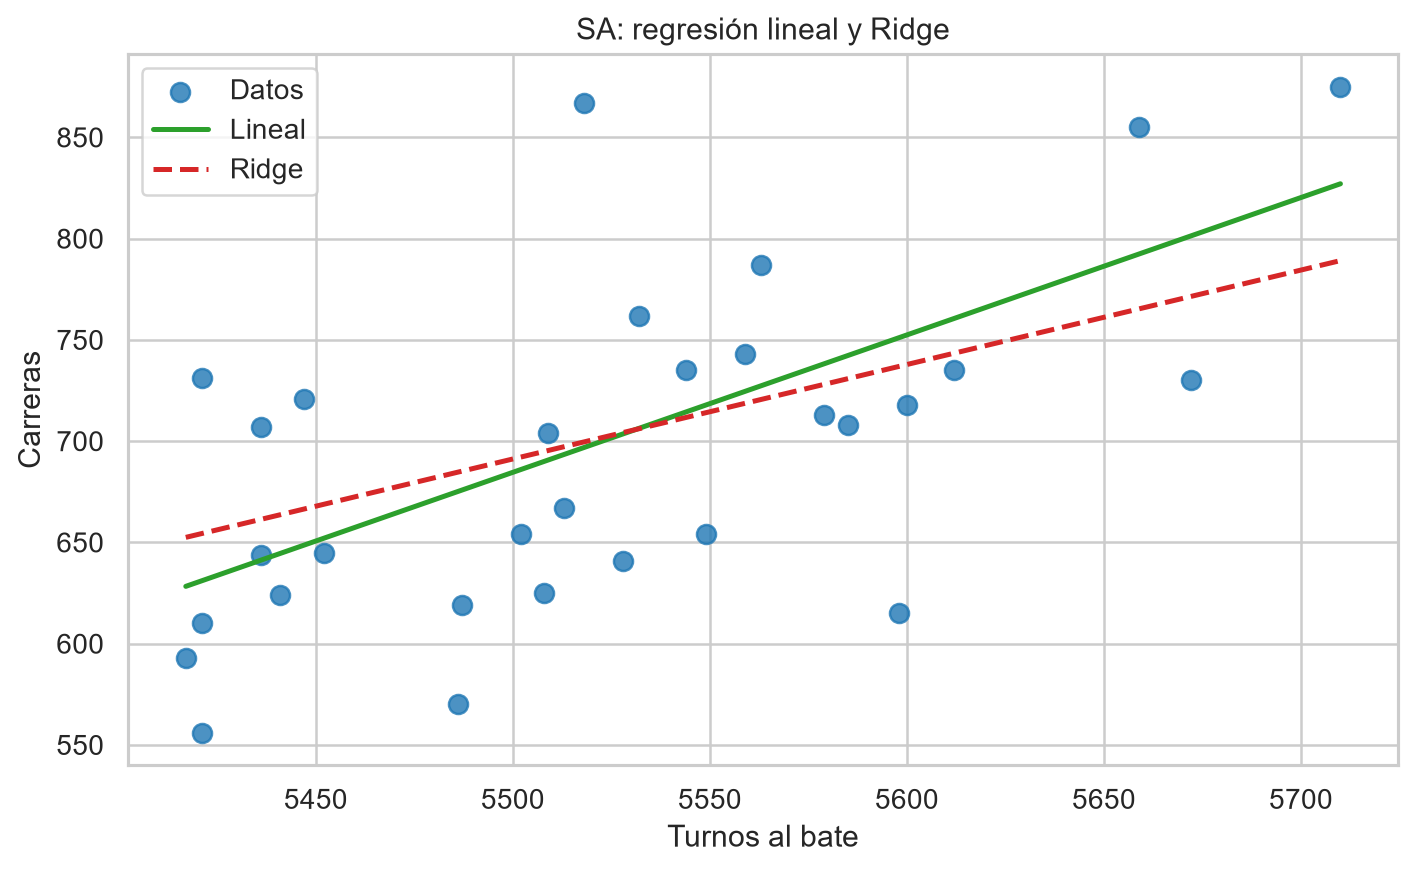

In [ ]:
eje = pd.DataFrame({
    "bateos": np.linspace(datos["bateos"].min(), datos["bateos"].max(), 200)
})

plt.figure(figsize=(8, 5))
plt.scatter(datos["bateos"], datos["runs"], label="Datos")
plt.plot(eje["bateos"], lineal.predict(eje), label="Lineal")
plt.plot(eje["bateos"], busqueda.predict(eje), "--", label="Ridge")
plt.xlabel("Turnos al bate")
plt.ylabel("Carreras")
plt.title("Regresión lineal y Ridge")
plt.legend()
plt.show()

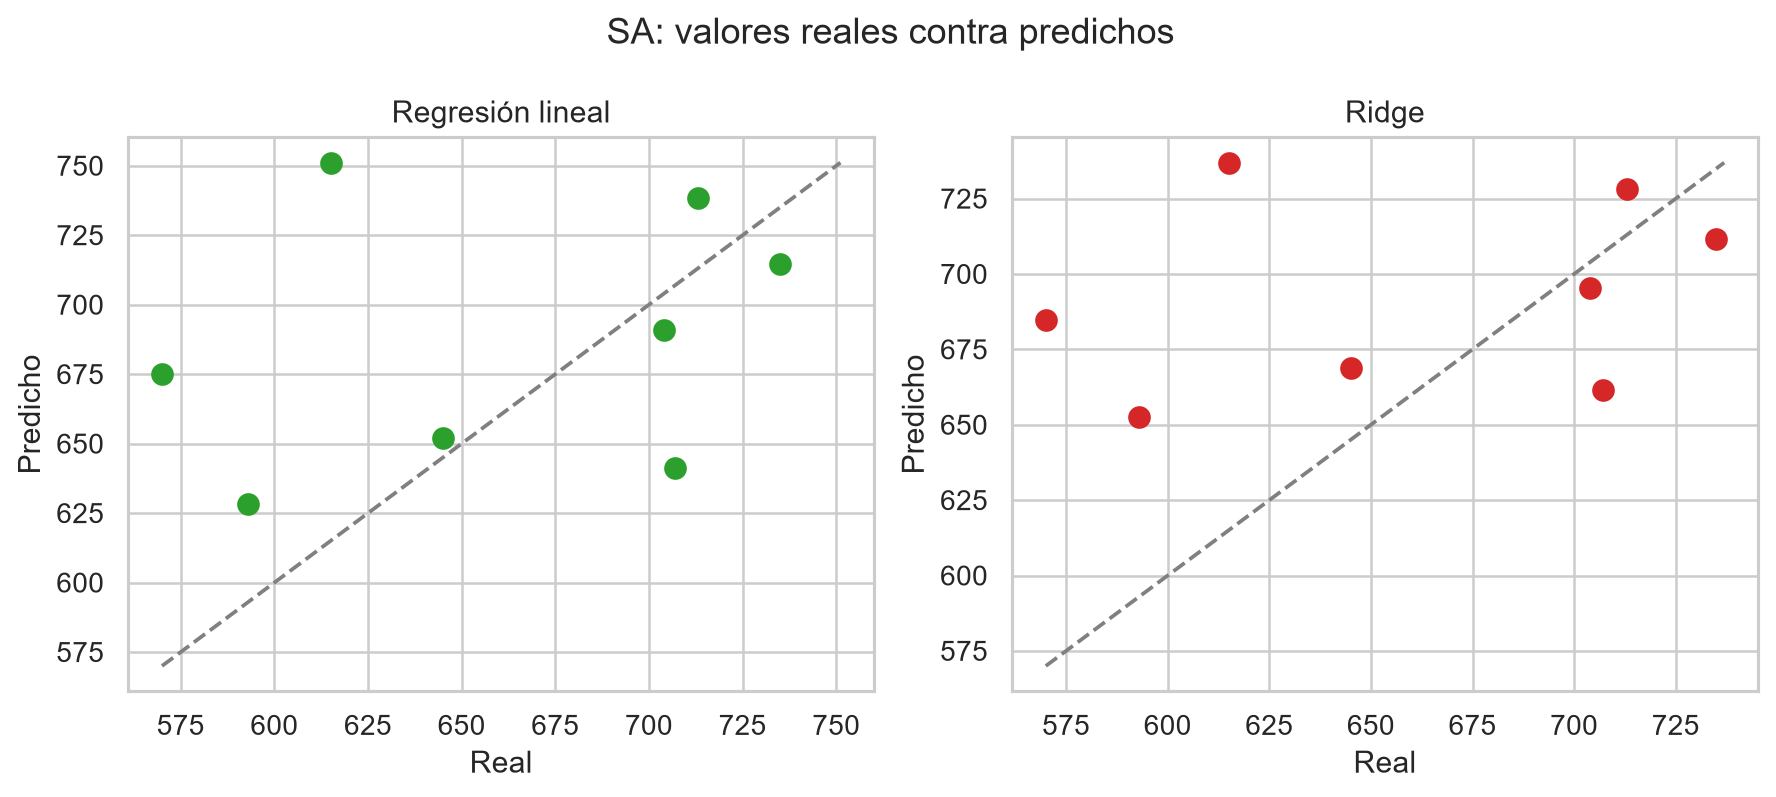

In [ ]:
figura, ejes = plt.subplots(1, 2, figsize=(10, 4))

for grafica, prediccion, nombre in zip(
    ejes,
    [pred_lineal, pred_ridge],
    ["Lineal", "Ridge"],
):
    grafica.scatter(y_prueba, prediccion)
    minimo = min(y_prueba.min(), prediccion.min())
    maximo = max(y_prueba.max(), prediccion.max())
    grafica.plot([minimo, maximo], [minimo, maximo], "--", color="gray")
    grafica.set_title(nombre)
    grafica.set_xlabel("Real")
    grafica.set_ylabel("Predicho")

plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(lineal, ruta / "models" / "sa_regresion_lineal_beisbol.joblib")
joblib.dump(busqueda.best_estimator_, ruta / "models" / "sa_ridge_beisbol.joblib")

## Interpretación

Ridge obtuvo un error ligeramente menor. El R² de prueba es negativo en ambos casos, así que `bateos` por sí solo no explica bien las carreras fuera de la muestra usada para entrenar.